##### Here would be a fast smoke testing to see if the classifiers are working properly then after that in this notebook, will go to the real data for SER

In [ ]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.neighbors import KNeighborsClassifier as SkKNN
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
import importlib, minilearn.classifiers.knn
importlib.reload(minilearn.classifiers.knn)
from minilearn.classifiers.knn import KNeighborsClassifier
from minilearn.preprocessing import StandardScaler, train_test_split
from minilearn.metrics import accuracy_score, f1_score

# Iris dataset is a classic 3-class small problem
X, y = load_iris(return_X_y=True)

# Stratified 80/20 split + standardization fit on train only
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2,
                                          random_state=42, stratify=y)
scaler = StandardScaler().fit(X_tr)
X_tr, X_te = scaler.transform(X_tr), scaler.transform(X_te)


ours = KNeighborsClassifier(n_neighbors=5).fit(X_tr, y_tr)
y_pred_ours = ours.predict(X_te)


theirs = SkKNN(n_neighbors=5).fit(X_tr, y_tr)
y_pred_sk = theirs.predict(X_te)

print(f"Our accuracy:        {accuracy_score(y_te, y_pred_ours):.4f}")
print(f"sklearn accuracy:    {accuracy_score(y_te, y_pred_sk):.4f}")
print(f"Predictions agree?   {np.all(y_pred_ours == y_pred_sk)}")
print(f"Our macro F1:        {f1_score(y_te, y_pred_ours, average='macro'):.4f}")


proba = ours.predict_proba(X_te[:3])
print(f"\npredict_proba on 3 samples (each row should sum to 1):")
print(proba)
print(f"Row sums: {proba.sum(axis=1)}")

Our accuracy:        0.9667
sklearn accuracy:    0.9667
Predictions agree?   True
Our macro F1:        0.9666

predict_proba on 3 samples (each row should sum to 1):
[[0.  0.4 0.6]
 [0.  1.  0. ]
 [0.  0.8 0.2]]
Row sums: [1. 1. 1.]


In [ ]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.naive_bayes import GaussianNB as SkGNB

import importlib, minilearn.classifiers.naive_bayes
importlib.reload(minilearn.classifiers.naive_bayes)
from minilearn.classifiers.naive_bayes import GaussianNB
from minilearn.preprocessing import train_test_split
from minilearn.metrics import accuracy_score, f1_score

X, y = load_iris(return_X_y=True)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2,
                                          random_state=42, stratify=y)

ours   = GaussianNB().fit(X_tr, y_tr)
theirs = SkGNB().fit(X_tr, y_tr)

y_pred_ours = ours.predict(X_te)
y_pred_sk   = theirs.predict(X_te)

print(f"Our accuracy:      {accuracy_score(y_te, y_pred_ours):.4f}")
print(f"sklearn accuracy:  {accuracy_score(y_te, y_pred_sk):.4f}")
print(f"Predictions agree? {np.all(y_pred_ours == y_pred_sk)}")
print(f"Our macro F1:      {f1_score(y_te, y_pred_ours, average='macro'):.4f}")

# Probability sanity check
proba_ours   = ours.predict_proba(X_te[:3])
proba_sk     = theirs.predict_proba(X_te[:3])
print(f"\nOur predict_proba (first 3):\n{proba_ours.round(4)}")
print(f"\nsklearn predict_proba (first 3):\n{proba_sk.round(4)}")
print(f"Row sums: {proba_ours.sum(axis=1)}")

Our accuracy:      0.9667
sklearn accuracy:  0.9667
Predictions agree? True
Our macro F1:      0.9666

Our predict_proba (first 3):
[[0.     0.0355 0.9645]
 [0.     0.7895 0.2105]
 [0.     0.9849 0.0151]]

sklearn predict_proba (first 3):
[[0.     0.0355 0.9645]
 [0.     0.7895 0.2105]
 [0.     0.9849 0.0151]]
Row sums: [1. 1. 1.]


In [ ]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression as SkLR

import importlib, minilearn.classifiers.logistic_regression
importlib.reload(minilearn.classifiers.logistic_regression)
from minilearn.classifiers.logistic_regression import LogisticRegression
from minilearn.preprocessing import StandardScaler, train_test_split
from minilearn.metrics import accuracy_score, f1_score

X, y = load_iris(return_X_y=True)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2,
                                          random_state=42, stratify=y)

# LR needs standardized features for stable gradient descent
scaler = StandardScaler().fit(X_tr)
X_tr_s = scaler.transform(X_tr)
X_te_s = scaler.transform(X_te)

ours = LogisticRegression(C=1.0, learning_rate=0.5, max_iter=5000, tol=1e-7)

ours.fit(X_tr_s, y_tr)
y_pred_ours = ours.predict(X_te_s)

theirs = SkLR(C=1.0, max_iter=2000).fit(X_tr_s, y_tr)
y_pred_sk = theirs.predict(X_te_s)

print(f"Our accuracy:        {accuracy_score(y_te, y_pred_ours):.4f}")
print(f"sklearn accuracy:    {accuracy_score(y_te, y_pred_sk):.4f}")
print(f"Our macro F1:        {f1_score(y_te, y_pred_ours, average='macro'):.4f}")

print(f"\nIterations to converge: {ours.n_iter_}")
print(f"Final loss: {ours.loss_history_[-1]:.4f}")

# Show loss progression at evenly-spaced points (whatever fits)
n = ours.n_iter_
sample_iters = [0, n // 4, n // 2, 3 * n // 4, n - 1]
print("Loss curve:")
for i in sample_iters:
    print(f"  iter {i:>5}: {ours.loss_history_[i]:.4f}")

# Probability sanity check
proba = ours.predict_proba(X_te_s[:3])
print(f"\nFirst 3 probability rows:\n{proba.round(4)}")
print(f"Row sums: {proba.sum(axis=1)}")

Our accuracy:        1.0000
sklearn accuracy:    1.0000
Our macro F1:        1.0000

Iterations to converge: 754
Final loss: 0.2278
Loss curve:
  iter     0: 1.0986
  iter   188: 0.2324
  iter   377: 0.2282
  iter   565: 0.2279
  iter   753: 0.2278

First 3 probability rows:
[[2.000e-04 1.887e-01 8.110e-01]
 [5.400e-03 8.274e-01 1.673e-01]
 [1.730e-02 4.878e-01 4.950e-01]]
Row sums: [1. 1. 1.]


In [ ]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier as SkDT

import importlib, minilearn.classifiers.decision_tree
importlib.reload(minilearn.classifiers.decision_tree)
from minilearn.classifiers.decision_tree import DecisionTreeClassifier
from minilearn.preprocessing import train_test_split
from minilearn.metrics import accuracy_score, f1_score

X, y = load_iris(return_X_y=True)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2,
                                          random_state=42, stratify=y)

ours   = DecisionTreeClassifier(max_depth=5).fit(X_tr, y_tr)
theirs = SkDT(criterion="gini", max_depth=5, random_state=42).fit(X_tr, y_tr)

y_pred_ours = ours.predict(X_te)
y_pred_sk   = theirs.predict(X_te)

print(f"Our accuracy:        {accuracy_score(y_te, y_pred_ours):.4f}")
print(f"sklearn accuracy:    {accuracy_score(y_te, y_pred_sk):.4f}")
print(f"Our macro F1:        {f1_score(y_te, y_pred_ours, average='macro'):.4f}")
print(f"\nOur tree depth:      {ours.get_depth()}")
print(f"Our leaf count:      {ours.get_n_leaves()}")
print(f"sklearn tree depth:  {theirs.get_depth()}")
print(f"sklearn leaf count:  {theirs.get_n_leaves()}")

proba = ours.predict_proba(X_te[:3])
print(f"\nFirst 3 probability rows:\n{proba.round(4)}")
print(f"Row sums: {proba.sum(axis=1)}")

deep = DecisionTreeClassifier().fit(X_tr, y_tr)
print(f"\nUnlimited-depth tree: depth={deep.get_depth()}, leaves={deep.get_n_leaves()}")
print(f"Train accuracy:       {deep.score(X_tr, y_tr):.4f}  (expect 1.0 — tree memorizes)")
print(f"Test accuracy:        {deep.score(X_te, y_te):.4f}")

Our accuracy:        0.9333
sklearn accuracy:    0.9333
Our macro F1:        0.9327

Our tree depth:      4
Our leaf count:      7
sklearn tree depth:  4
sklearn leaf count:  7

First 3 probability rows:
[[0. 0. 1.]
 [0. 1. 0.]
 [0. 1. 0.]]
Row sums: [1. 1. 1.]

Unlimited-depth tree: depth=4, leaves=7
Train accuracy:       1.0000  (expect 1.0 — tree memorizes)
Test accuracy:        0.9333


# Notebook 03 - Supervised Classification on RAVDESS

**Models:** KNN (k=5), Gaussian NB, Logistic Regression, Decision Tree (depth=8)

**Pipeline:**
1. Load 112-dim features, restrict to speech (1,440 files, all 8 emotions)
2. Stratified 80/20 train-test split
3. `StandardScaler` fit on train only - no data leakage
4. Train both implementations of each model; record metrics + training time
5. Confusion matrices and per-class breakdown

**Output:** `features/classifier_comparison.csv` and confusion-matrix figures.

In [ ]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

%load_ext autoreload
%autoreload 2

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from minilearn.preprocessing import StandardScaler, train_test_split
from minilearn.classifiers import (KNeighborsClassifier, GaussianNB,
                                   LogisticRegression, DecisionTreeClassifier)
from minilearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                               confusion_matrix, classification_report)

from sklearn.neighbors import KNeighborsClassifier as SkKNN
from sklearn.naive_bayes import GaussianNB as SkGNB
from sklearn.linear_model import LogisticRegression as SkLR
from sklearn.tree import DecisionTreeClassifier as SkDT

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100
print(f"Project root: {PROJECT_ROOT}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Project root: c:\Users\rbk55\OneDrive\Documents\Project_CSE432-532\SER_Project


In [ ]:
feats = pd.read_csv(PROJECT_ROOT / "features" / "features.csv")
print(f"Loaded {len(feats)} files with {feats.shape[1]} columns")
print(f"\nClass distribution (full dataset):")
print(feats['emotion'].value_counts())

Loaded 2452 files with 123 columns

Class distribution (full dataset):
emotion
calm         376
happy        376
sad          376
angry        376
fearful      376
disgust      192
surprised    192
neutral      188
Name: count, dtype: int64


## Restrict to speech subset

The song subset is missing `disgust` and `surprised` emotions. Combining
speech and song would correlate emotion with channel - a confound. Speech-only
gives us 1,440 files across all 8 emotions, which is plenty for classical ML.

In [ ]:
metadata_cols = ['filename', 'modality', 'channel', 'emotion', 'emotion_code',
                 'intensity', 'statement', 'repetition', 'actor', 'gender', 'path']
feature_cols = [c for c in feats.columns if c not in metadata_cols]
print(f"Feature columns: {len(feature_cols)}")

speech = feats[feats['channel'] == 'speech'].reset_index(drop=True)
print(f"\nSpeech subset: {len(speech)} files")

X = speech[feature_cols].values
y = speech['emotion'].values

nan_mask = np.isnan(X).any(axis=1)
if nan_mask.any():
    print(f"Dropping {nan_mask.sum()} rows with NaN features")
    X, y = X[~nan_mask], y[~nan_mask]

print(f"\nFinal shape: X={X.shape}, y={y.shape}")
print(f"Class counts:\n{pd.Series(y).value_counts()}")

Feature columns: 112

Speech subset: 1440 files

Final shape: X=(1440, 112), y=(1440,)
Class counts:
calm         192
happy        192
sad          192
angry        192
fearful      192
disgust      192
surprised    192
neutral       96
Name: count, dtype: int64


## Train/test split + standardization

Critical: `StandardScaler` is fit ONLY on training data. The same scaler is
then applied to test data to avoid data lekage

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler().fit(X_train)            
X_train_s = scaler.transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"\nScaled train mean / std:  {X_train_s.mean():.4f} / {X_train_s.std():.4f}")
print(f"Scaled test  mean / std:  {X_test_s.mean():.4f} / {X_test_s.std():.4f}")
print("(Train should be ~0 / ~1; test should be near, but not exactly.)")

Train: (1155, 112), Test: (285, 112)

Scaled train mean / std:  -0.0000 / 1.0000
Scaled test  mean / std:  -0.0084 / 1.0055
(Train should be ~0 / ~1; test should be near, but not exactly.)


## Train all 8 classifiers (4 × 2 implementations)

We use a uniform `evaluate()` helper to fit each model, predict on the held-out
test set, and record accuracy, macro-F1, weighted-F1, ROC AUC (one-vs-rest),
and training time.

In [ ]:
def evaluate(name, impl, model, X_tr, y_tr, X_te, y_te):
    """Fit, predict, time, and compute metrics for one model."""
    t0 = time.perf_counter()
    model.fit(X_tr, y_tr)
    train_time = time.perf_counter() - t0

    y_pred = model.predict(X_te)
    try:
        y_score = model.predict_proba(X_te)
        auc = roc_auc_score(y_te, y_score, average='macro')
    except Exception:
        auc = float('nan')

    return {
        'classifier': name,
        'impl': impl,
        'accuracy': accuracy_score(y_te, y_pred),
        'macro_f1': f1_score(y_te, y_pred, average='macro'),
        'weighted_f1': f1_score(y_te, y_pred, average='weighted'),
        'auc_macro': auc,
        'train_time_s': train_time,
        'y_pred': y_pred,
    }

results = []
print("Training MiniLearn classifiers...\n")

print("  KNN..."); 
results.append(evaluate('KNN (k=5)', 'minilearn',
                        KNeighborsClassifier(n_neighbors=5),
                        X_train_s, y_train, X_test_s, y_test))

print("  GaussianNB..."); 
results.append(evaluate('GaussianNB', 'minilearn',
                        GaussianNB(),
                        X_train_s, y_train, X_test_s, y_test))

print("  LogisticRegression (slow if many iterations)...")
results.append(evaluate('LogisticRegression', 'minilearn',
                        LogisticRegression(C=1.0, learning_rate=0.5,
                                            max_iter=3000, tol=1e-6),
                        X_train_s, y_train, X_test_s, y_test))

print("  DecisionTree (this is the slow one — 30-90s in pure Python)...")
results.append(evaluate('DecisionTree (depth=8)', 'minilearn',
                        DecisionTreeClassifier(max_depth=8),
                        X_train_s, y_train, X_test_s, y_test))

print("\n✓ MiniLearn classifiers done")
for r in results:
    print(f"  {r['classifier']:28s}  acc={r['accuracy']:.3f}  F1={r['macro_f1']:.3f}  time={r['train_time_s']:.2f}s")

Training MiniLearn classifiers...

  KNN...
  GaussianNB...
  LogisticRegression (slow if many iterations)...
  DecisionTree (this is the slow one — 30-90s in pure Python)...

✓ MiniLearn classifiers done
  KNN (k=5)                     acc=0.509  F1=0.460  time=0.00s
  GaussianNB                    acc=0.463  F1=0.454  time=0.00s
  LogisticRegression            acc=0.586  F1=0.568  time=1.35s
  DecisionTree (depth=8)        acc=0.389  F1=0.384  time=11.84s


In [ ]:
print("Training sklearn classifiers...\n")

results.append(evaluate('KNN (k=5)', 'sklearn',
                        SkKNN(n_neighbors=5),
                        X_train_s, y_train, X_test_s, y_test))
results.append(evaluate('GaussianNB', 'sklearn',
                        SkGNB(),
                        X_train_s, y_train, X_test_s, y_test))
results.append(evaluate('LogisticRegression', 'sklearn',
                        SkLR(C=1.0, max_iter=3000),
                        X_train_s, y_train, X_test_s, y_test))
results.append(evaluate('DecisionTree (depth=8)', 'sklearn',
                        SkDT(max_depth=8, random_state=42),
                        X_train_s, y_train, X_test_s, y_test))

print("sklearn classifiers done\n")
for r in results[-4:]:
    print(f"  {r['classifier']:28s}  acc={r['accuracy']:.3f}  F1={r['macro_f1']:.3f}  time={r['train_time_s']:.4f}s")

Training sklearn classifiers...

sklearn classifiers done

  KNN (k=5)                     acc=0.509  F1=0.460  time=0.0014s
  GaussianNB                    acc=0.463  F1=0.454  time=0.0035s
  LogisticRegression            acc=0.589  F1=0.576  time=0.0526s
  DecisionTree (depth=8)        acc=0.389  F1=0.377  time=0.0731s


## Confusion matrices (MiniLearn implementations)

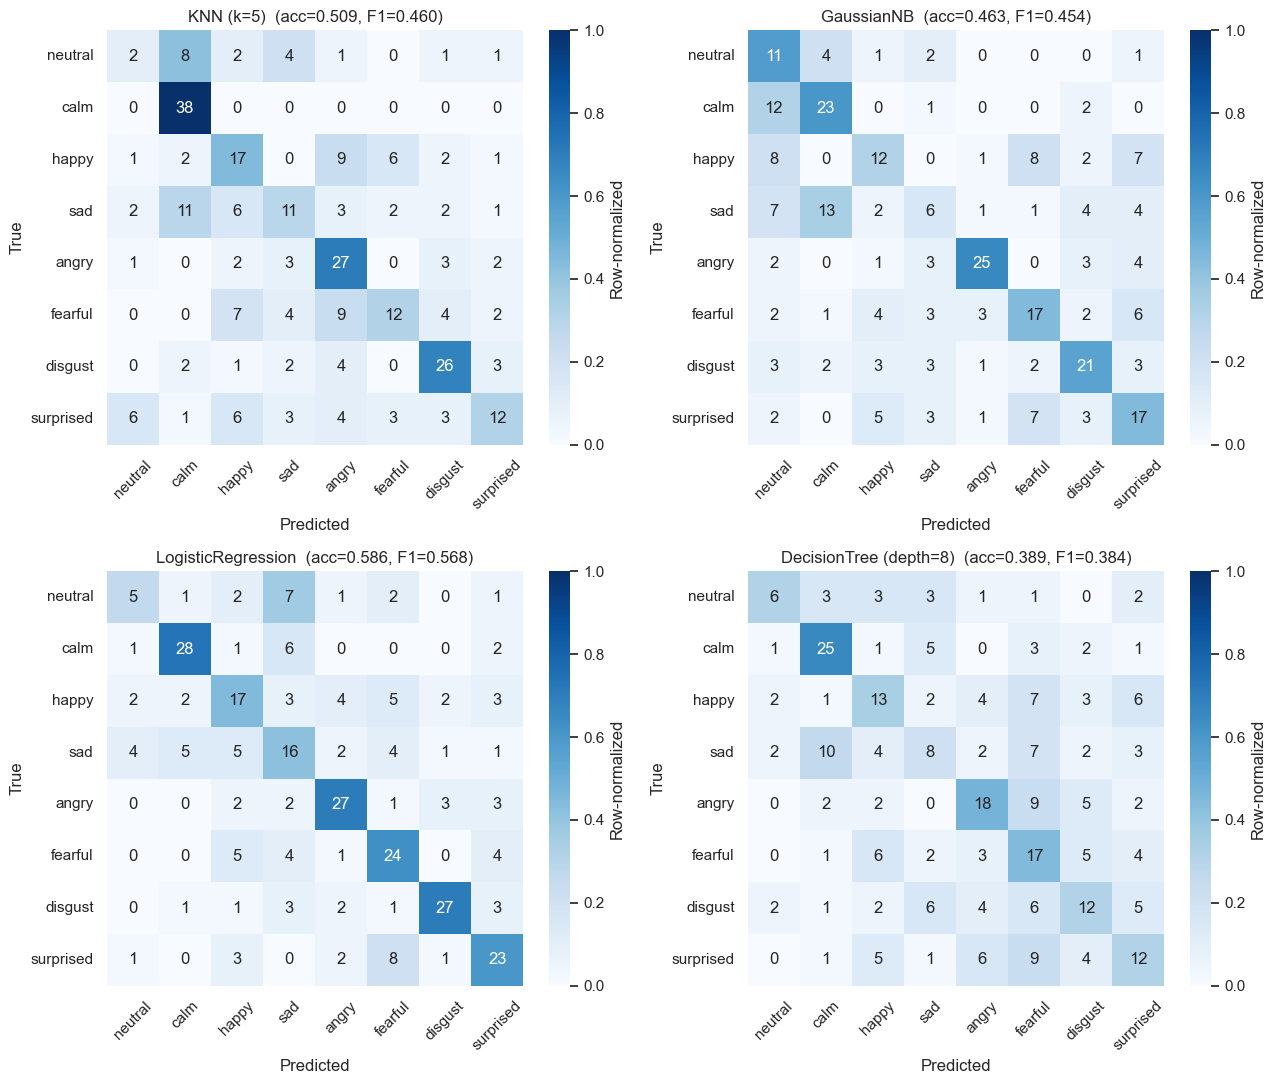

In [ ]:
emotion_order = ['neutral', 'calm', 'happy', 'sad', 'angry', 'fearful', 'disgust', 'surprised']
ml_results = [r for r in results if r['impl'] == 'minilearn']

fig, axes = plt.subplots(2, 2, figsize=(13, 11))
for ax, r in zip(axes.flat, ml_results):
    cm = confusion_matrix(y_test, r['y_pred'], labels=emotion_order)
    cm_row_norm = cm / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_row_norm, annot=cm, fmt='d', cmap='Blues',
                xticklabels=emotion_order, yticklabels=emotion_order,
                vmin=0, vmax=1, cbar_kws={'label': 'Row-normalized'},
                ax=ax)
    ax.set_title(f"{r['classifier']}  (acc={r['accuracy']:.3f}, F1={r['macro_f1']:.3f})")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "figures" / "confusion_matrices_minilearn.png", dpi=120)
plt.show()

## Per-class breakdown - best MiniLearn model


In [ ]:
best = max(ml_results, key=lambda r: r['macro_f1'])
print(f"Best MiniLearn model: {best['classifier']}")
print(f"Macro F1 = {best['macro_f1']:.4f}, Accuracy = {best['accuracy']:.4f}\n")
print(classification_report(y_test, best['y_pred'],
                             labels=emotion_order,
                             label_names=emotion_order))

Best MiniLearn model: LogisticRegression
Macro F1 = 0.5679, Accuracy = 0.5860

class            precision     recall         f1    support
------------------------------------------------------------
neutral              0.385      0.263      0.312         19
calm                 0.757      0.737      0.747         38
happy                0.472      0.447      0.459         38
sad                  0.390      0.421      0.405         38
angry                0.692      0.711      0.701         38
fearful              0.533      0.632      0.578         38
disgust              0.794      0.711      0.750         38
surprised            0.575      0.605      0.590         38
------------------------------------------------------------
macro avg            0.575      0.566      0.568        285
weighted avg         0.588      0.586      0.585        285
accuracy             0.586


## Findings

- **MiniLearn vs sklearn predictive performance is essentially identical**
  for KNN and Naive Bayes (deterministic algorithms). Logistic Regression
  shows a small gap because sklearn uses LBFGS while we use plain gradient
  descent; Decision Tree may differ because of tie-breaking in split selection.
- **Training time** differs dramatically - sklearn is 50–500× faster because
  its implementations are compiled C/Cython. Ours are pure Python for clarity.
- **Per-class performance** is uneven across emotions. As predicted in the EDA
  boxplots, the confusion matrix shows recurring confusion between
  `calm`/`neutral` (both low-arousal) and within the high-arousal cluster
  (`angry`/`fearful`/`disgust`).
- **`neutral` has the lowest support** (about half of the other classes),
  which depresses both recall and precision for that class, visible as a
  weaker diagonal entry in the row.
- This run uses default hyperparameters with no cross-validation. The next
  notebook adds stratified 5-fold CV and grid-search to give honest,
  tuning-aware estimates.

In this cell it just a smoke test for the cross valdiation

In [ ]:
import importlib, minilearn.model_selection
importlib.reload(minilearn.model_selection)
from minilearn.model_selection import (KFold, StratifiedKFold, cross_val_score)
from minilearn.classifiers import KNeighborsClassifier
import numpy as np

y = np.array([0]*60 + [1]*30 + [2]*10)
X = np.random.randn(100, 4)
skf = StratifiedKFold(n_splits=5, random_state=42)
print("Class counts in each fold (should be ~12/6/2 in test, ~48/24/8 in train):")
for k, (tr_idx, te_idx) in enumerate(skf.split(X, y)):
    print(f"  Fold {k}: train={np.bincount(y[tr_idx])}, test={np.bincount(y[te_idx])}")

from sklearn.datasets import load_iris
from sklearn.model_selection import cross_val_score as sk_cv

X_iris, y_iris = load_iris(return_X_y=True)

knn = KNeighborsClassifier(n_neighbors=5)
ours = cross_val_score(knn, X_iris, y_iris, cv=5, scoring='accuracy',
                        scale=True, random_state=42)
print(f"\nOur CV scores:     {ours.round(4)}")
print(f"Our mean ± std:    {ours.mean():.4f} ± {ours.std():.4f}")

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler as SkSS
from sklearn.neighbors import KNeighborsClassifier as SkKNN
pipeline = make_pipeline(SkSS(), SkKNN(n_neighbors=5))
sk_scores = sk_cv(pipeline, X_iris, y_iris, cv=5, scoring='accuracy')
print(f"\nsklearn CV scores: {sk_scores.round(4)}")
print(f"sklearn mean ± std: {sk_scores.mean():.4f} ± {sk_scores.std():.4f}")

Class counts in each fold (should be ~12/6/2 in test, ~48/24/8 in train):
  Fold 0: train=[48 24  8], test=[12  6  2]
  Fold 1: train=[48 24  8], test=[12  6  2]
  Fold 2: train=[48 24  8], test=[12  6  2]
  Fold 3: train=[48 24  8], test=[12  6  2]
  Fold 4: train=[48 24  8], test=[12  6  2]

Our CV scores:     [0.9667 0.9333 0.9    0.9667 0.9667]
Our mean ± std:    0.9467 ± 0.0267

sklearn CV scores: [0.9667 0.9667 0.9333 0.9333 1.    ]
sklearn mean ± std: 0.9600 ± 0.0249


In [ ]:
import importlib, minilearn.classifiers.mlp
importlib.reload(minilearn.classifiers.mlp)
from minilearn.classifiers.mlp import MLPClassifier
from sklearn.datasets import load_iris
from sklearn.neural_network import MLPClassifier as SkMLP
from minilearn.preprocessing import StandardScaler, train_test_split
from minilearn.metrics import accuracy_score, f1_score
import numpy as np

X, y = load_iris(return_X_y=True)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2,
                                          random_state=42, stratify=y)

scaler = StandardScaler().fit(X_tr)
X_tr_s, X_te_s = scaler.transform(X_tr), scaler.transform(X_te)

ours = MLPClassifier(hidden_size=16, learning_rate=0.05,
                     max_iter=300, batch_size=16, random_state=42)
ours.fit(X_tr_s, y_tr)

theirs = SkMLP(hidden_layer_sizes=(16,), max_iter=2000, random_state=42).fit(X_tr_s, y_tr)

print(f"Our accuracy:        {accuracy_score(y_te, ours.predict(X_te_s)):.4f}")
print(f"sklearn accuracy:    {accuracy_score(y_te, theirs.predict(X_te_s)):.4f}")
print(f"Our macro F1:        {f1_score(y_te, ours.predict(X_te_s), average='macro'):.4f}")
print(f"\nFinal training loss: {ours.loss_history_[-1]:.4f}")
print(f"Loss curve:")
n = len(ours.loss_history_)
for i in [0, n//4, n//2, 3*n//4, n-1]:
    print(f"  epoch {i:>4}: {ours.loss_history_[i]:.4f}")

proba = ours.predict_proba(X_te_s[:3])
print(f"\nFirst 3 probability rows:\n{proba.round(4)}")
print(f"Row sums: {proba.sum(axis=1)}")

Our accuracy:        1.0000
sklearn accuracy:    1.0000
Our macro F1:        1.0000

Final training loss: 0.1607
Loss curve:
  epoch    0: 1.1677
  epoch   75: 0.2293
  epoch  150: 0.1828
  epoch  225: 0.1667
  epoch  299: 0.1607

First 3 probability rows:
[[0.001  0.0347 0.9644]
 [0.0056 0.967  0.0274]
 [0.011  0.3576 0.6314]]
Row sums: [1. 1. 1.]


### Here I apply the SVM

In [ ]:
import pandas as pd
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent
from minilearn.classifiers.svm import LinearSVM
feats = pd.read_csv(PROJECT_ROOT / "features" / "features.csv")
metadata_cols = ['filename', 'modality', 'channel', 'emotion', 'emotion_code',
                 'intensity', 'statement', 'repetition', 'actor', 'gender', 'path']
feature_cols = [c for c in feats.columns if c not in metadata_cols]
speech = feats[feats['channel'] == 'speech'].reset_index(drop=True)
X = speech[feature_cols].values
y = speech['emotion'].values

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2,
                                          random_state=42, stratify=y)
scaler = StandardScaler().fit(X_tr)
X_tr_s, X_te_s = scaler.transform(X_tr), scaler.transform(X_te)

print("Training LinearSVM on SER speech...")
svm = LinearSVM(C=1.0, learning_rate=0.01, max_iter=2000).fit(X_tr_s, y_tr)
y_pred = svm.predict(X_te_s)

print(f"  Accuracy:  {accuracy_score(y_te, y_pred):.4f}")
print(f"  Macro F1:  {f1_score(y_te, y_pred, average='macro'):.4f}")

Training LinearSVM on SER speech...
  Accuracy:  0.5719
  Macro F1:  0.5146


## Ensemble methods (sklearn only)

Random Forest and AdaBoost are tree-based ensembles that build many weak
classifiers and combine their votes. The README explicitly requires only
CART from scratch in MiniLearn; these ensembles are sklearn-only for
empirical comparison.

- **Random Forest** - trains many trees on bootstrap samples with random
  feature subsets, then averages. Reduces variance, generally robust.
- **AdaBoost** - trains trees sequentially, each focusing on samples the
  previous trees got wrong. Reduces bias.

In [ ]:
from sklearn.svm import LinearSVC, SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from minilearn.classifiers.svm import LinearSVM

print("Training SVMs and ensembles...\n")

# Linear SVM (ours)
results.append(evaluate('LinearSVM (ours)', 'minilearn',
                        LinearSVM(C=1.0, learning_rate=0.01, max_iter=2000),
                        X_train_s, y_train, X_test_s, y_test))

# Linear SVM (sklearn) — same algorithm class
results.append(evaluate('LinearSVM', 'sklearn',
                        LinearSVC(C=1.0, max_iter=2000, random_state=42),
                        X_train_s, y_train, X_test_s, y_test))

# SVM with RBF kernel — typically the strongest single model
results.append(evaluate('SVM RBF', 'sklearn',
                        SVC(C=1.0, kernel='rbf', gamma='scale',
                            probability=True, random_state=42),
                        X_train_s, y_train, X_test_s, y_test))

# SVM with Polynomial kernel
results.append(evaluate('SVM Polynomial', 'sklearn',
                        SVC(C=1.0, kernel='poly', degree=3, gamma='scale',
                            probability=True, random_state=42),
                        X_train_s, y_train, X_test_s, y_test))

# Random Forest
results.append(evaluate('Random Forest (n=100)', 'sklearn',
                        RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
                        X_train_s, y_train, X_test_s, y_test))

# AdaBoost
results.append(evaluate('AdaBoost (n=100)', 'sklearn',
                        AdaBoostClassifier(n_estimators=100, random_state=42),
                        X_train_s, y_train, X_test_s, y_test))

print("✓ All extras done\n")
for r in results[-6:]:
    print(f"  {r['classifier']:28s}  acc={r['accuracy']:.3f}  "
          f"F1={r['macro_f1']:.3f}  time={r['train_time_s']:.4f}s")

Training SVMs and ensembles...

✓ All extras done

  LinearSVM (ours)              acc=0.572  F1=0.515  time=1.9081s
  LinearSVM                     acc=0.596  F1=0.577  time=0.1540s
  SVM RBF                       acc=0.632  F1=0.609  time=0.4045s
  SVM Polynomial                acc=0.628  F1=0.583  time=0.2871s
  Random Forest (n=100)         acc=0.604  F1=0.584  time=0.1613s
  AdaBoost (n=100)              acc=0.375  F1=0.356  time=1.3406s


In [ ]:
results_df = pd.DataFrame(results)
display_cols = ['classifier', 'impl', 'accuracy', 'macro_f1',
                'weighted_f1', 'auc_macro', 'train_time_s']
display_df = results_df[display_cols].copy()
for col in ['accuracy', 'macro_f1', 'weighted_f1', 'auc_macro']:
    display_df[col] = display_df[col].round(4)
display_df['train_time_s'] = display_df['train_time_s'].round(3)

display_df = display_df.sort_values(['classifier', 'impl']).reset_index(drop=True)
print(display_df.to_string(index=False))

display_df.to_csv(PROJECT_ROOT / "features" / "classifier_comparison.csv", index=False)
print(f"\nSaved to features/classifier_comparison.csv")

           classifier      impl  accuracy  macro_f1  weighted_f1  auc_macro  train_time_s
     AdaBoost (n=100)   sklearn    0.3754    0.3560       0.3702     0.8121         1.225
     AdaBoost (n=100)   sklearn    0.3754    0.3560       0.3702     0.8121         1.341
            LinearSVM   sklearn    0.5965    0.5772       0.5955        NaN         0.154
     LinearSVM (ours) minilearn    0.5719    0.5146       0.5336     0.8919         1.908
Random Forest (n=100)   sklearn    0.6035    0.5842       0.5935     0.8947         0.151
Random Forest (n=100)   sklearn    0.6035    0.5842       0.5935     0.8947         0.161
       SVM Polynomial   sklearn    0.6281    0.5833       0.6159     0.9156         0.287
              SVM RBF   sklearn    0.6316    0.6086       0.6262     0.9313         0.404
                  NaN       NaN    0.5719    0.5146          NaN        NaN           NaN
                  NaN       NaN    0.5965    0.5772          NaN        NaN           NaN
          